In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv("diabetes.csv")

print(df.shape)
print(df.columns)
df.head()

(768, 9)
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [34]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

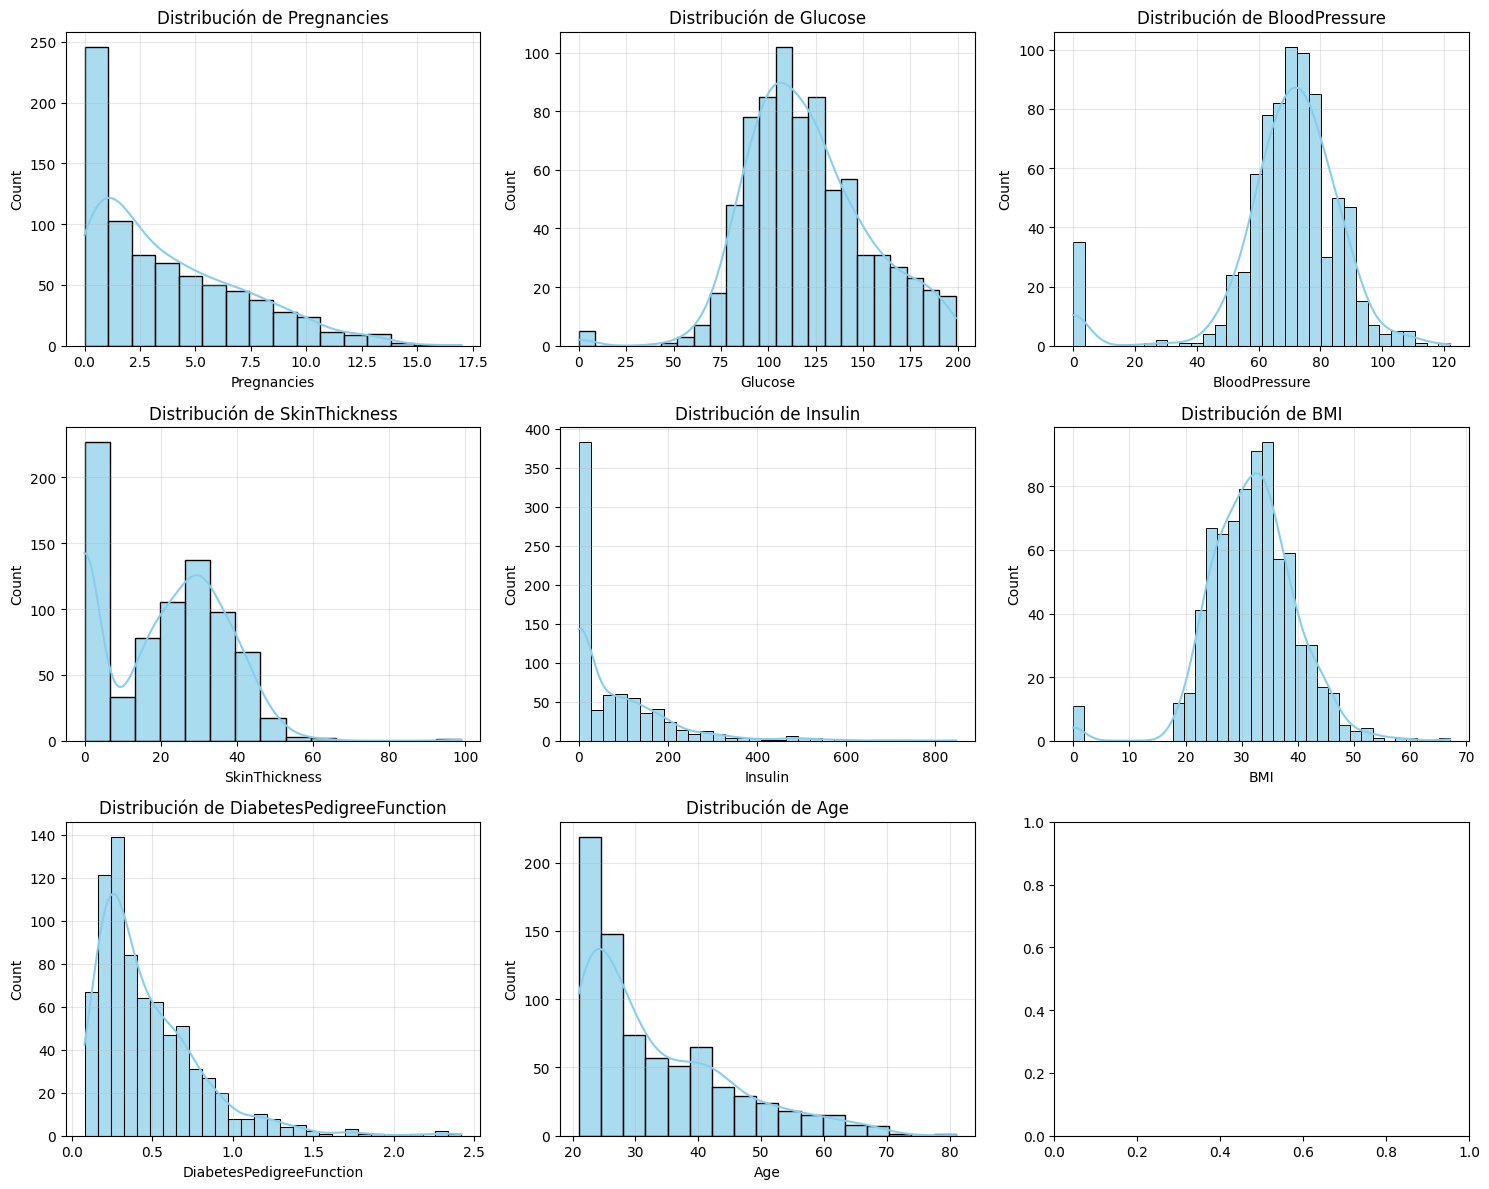

In [35]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(df.columns[:-1]):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color="skyblue", alpha=0.7)
    axes[i].set_title(f"Distribución de {col}")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

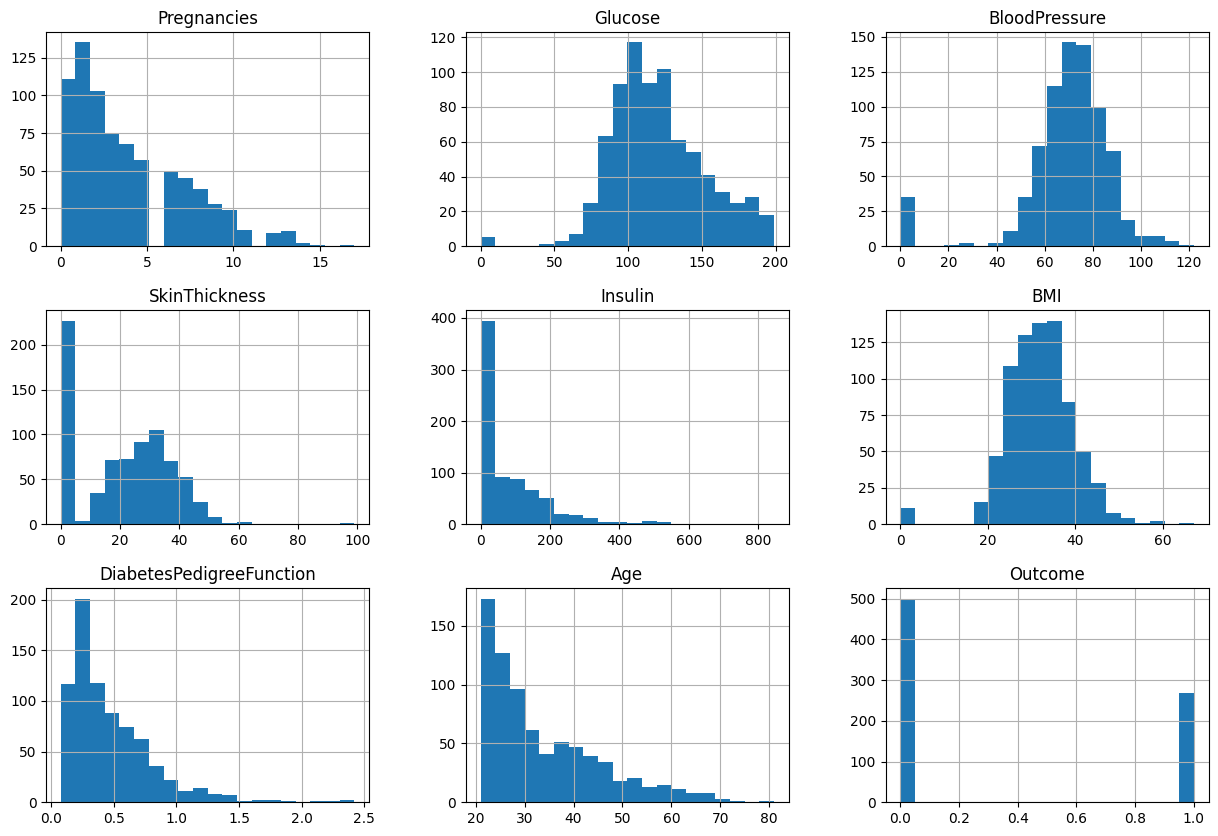

Text(0.5, 1.0, 'Distribución de Outcome (0=no diabetes, 1=diabetes)')

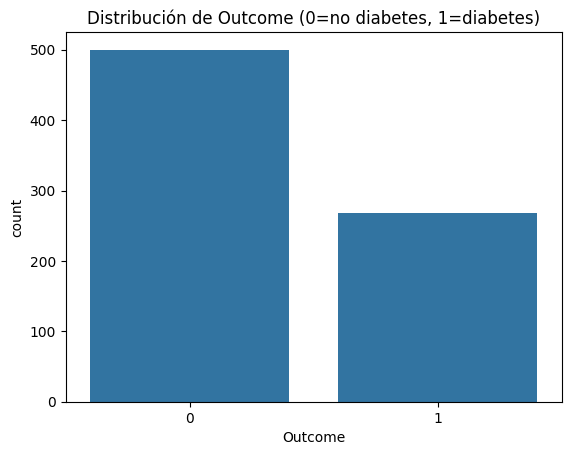

In [36]:
df.hist(bins=20, figsize=(15,10))
plt.show()

sns.countplot(x="Outcome", data=df)
plt.title("Distribución de Outcome (0=no diabetes, 1=diabetes)")

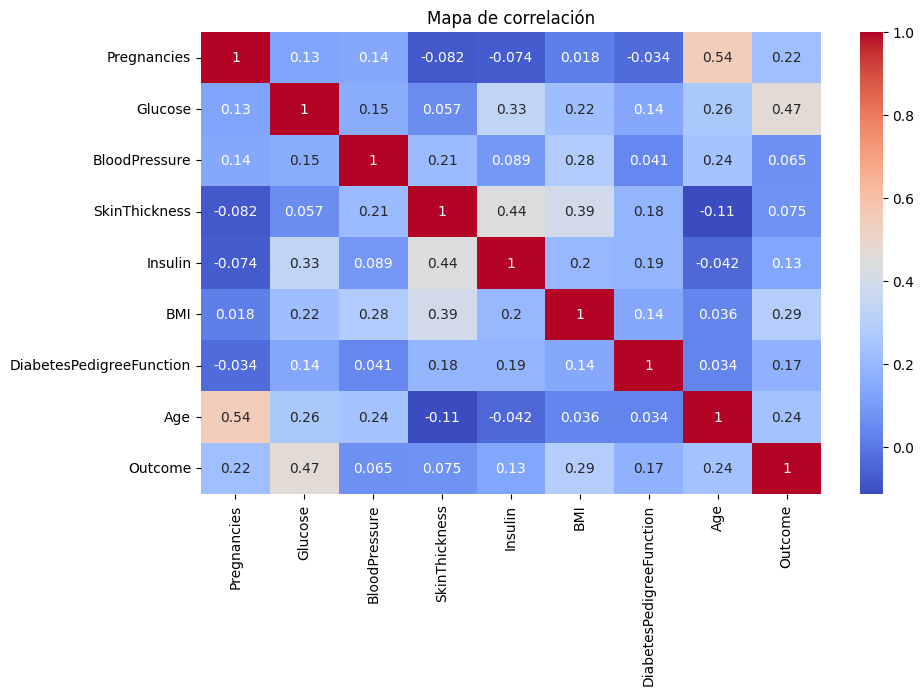

In [37]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Mapa de correlación")
plt.show()

Decision tree

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV

In [39]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [40]:
tree = DecisionTreeClassifier(criterion="gini", random_state=42)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7272727272727273
[[85 15]
 [27 27]]
              precision    recall  f1-score   support

           0       0.76      0.85      0.80       100
           1       0.64      0.50      0.56        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.68       154
weighted avg       0.72      0.73      0.72       154



In [41]:
tree = DecisionTreeClassifier(criterion="entropy", random_state=42)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7012987012987013
[[80 20]
 [26 28]]
              precision    recall  f1-score   support

           0       0.75      0.80      0.78       100
           1       0.58      0.52      0.55        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154



In [42]:
tree = DecisionTreeClassifier(criterion="log_loss", random_state=42)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7012987012987013
[[80 20]
 [26 28]]
              precision    recall  f1-score   support

           0       0.75      0.80      0.78       100
           1       0.58      0.52      0.55        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154



In [43]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)
grid.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor accuracy (cv):", grid.best_score_)

Mejores hiperparámetros: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mejor accuracy (cv): 0.7460082633613221


In [44]:
best_tree = grid.best_estimator_
print("Accuracy en test:", accuracy_score(y_test, best_tree.predict(X_test)))

Accuracy en test: 0.6948051948051948


In [45]:
import joblib

joblib.dump(best_tree, "decision_tree_diabetes.pkl")
print("Modelo guardado en decision_tree_diabetes.pkl")

Modelo guardado en decision_tree_diabetes.pkl


Rambom forest

In [46]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV


In [47]:
df = pd.read_csv("diabetes.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [48]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Resultados Random Forest (baseline)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Resultados Random Forest (baseline)
Accuracy: 0.7597402597402597
[[85 15]
 [22 32]]
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



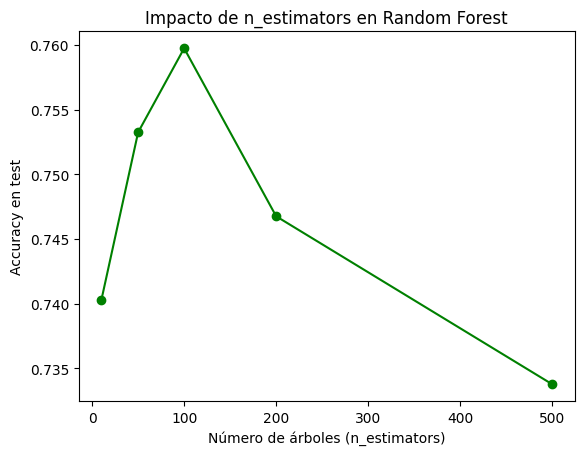

In [49]:
n_estimators_list = [10, 50, 100, 200, 500]
scores = []

for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    scores.append(rf.score(X_test, y_test))

plt.plot(n_estimators_list, scores, marker="o", color="green")
plt.xlabel("Número de árboles (n_estimators)")
plt.ylabel("Accuracy en test")
plt.title("Impacto de n_estimators en Random Forest")
plt.show()

In [50]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_features": ["sqrt", "log2", None],
    "max_depth": [5, 10, None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor accuracy:", grid.best_score_)

Mejores parámetros: {'max_depth': None, 'max_features': 'log2', 'n_estimators': 100}
Mejor accuracy: 0.776915900306544


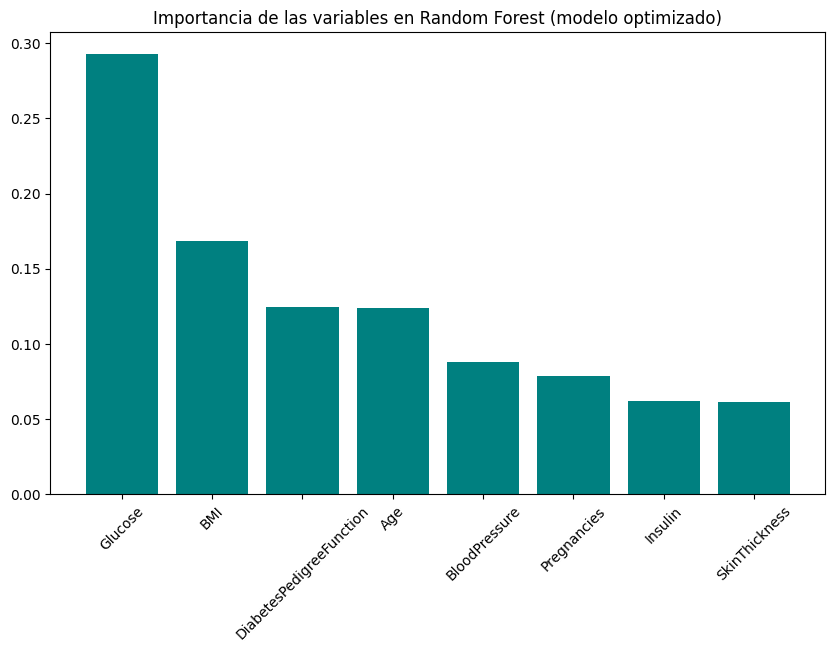

In [51]:
best_model = grid.best_estimator_

importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(X.shape[1]), importances[indices], align="center", color="teal")
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=45)
plt.title("Importancia de las variables en Random Forest (modelo optimizado)")
plt.show()

In [52]:
import joblib

joblib.dump(best_model, "random_forest_diabetes.pkl")
print("Modelo guardado como random_forest_diabetes.pkl")

Modelo guardado como random_forest_diabetes.pkl


In [53]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier


In [54]:
df = pd.read_csv("diabetes.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [55]:
ada = AdaBoostClassifier(random_state=42, n_estimators=100)
ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)

print("AdaBoost Results")
print("Accuracy:", accuracy_score(y_test, y_pred_ada))
print(confusion_matrix(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))

AdaBoost Results
Accuracy: 0.7922077922077922
[[86 14]
 [18 36]]
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       100
           1       0.72      0.67      0.69        54

    accuracy                           0.79       154
   macro avg       0.77      0.76      0.77       154
weighted avg       0.79      0.79      0.79       154



In [56]:
gb = GradientBoostingClassifier(random_state=42, n_estimators=100, learning_rate=0.1, max_depth=3)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Results")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Results
Accuracy: 0.7532467532467533
[[84 16]
 [22 32]]
              precision    recall  f1-score   support

           0       0.79      0.84      0.82       100
           1       0.67      0.59      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



In [57]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [2, 3, 4]
}

gb_clf = GradientBoostingClassifier(random_state=42)

grid = GridSearchCV(
    gb_clf,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor accuracy (cv):", grid.best_score_)

best_boost = grid.best_estimator_

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Mejores parámetros: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Mejor accuracy (cv): 0.7687991470078634


In [58]:
joblib.dump(best_boost, "boosting_diabetes.pkl")
print("Modelo de Boosting guardado como boosting_diabetes.pkl")

Modelo de Boosting guardado como boosting_diabetes.pkl


In [59]:
models = {
    "Decision Tree": tree,            
    "Random Forest": rf,               
    "Boosting": best_boost
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Decision Tree
Accuracy: 0.7012987012987013
[[80 20]
 [26 28]]
              precision    recall  f1-score   support

           0       0.75      0.80      0.78       100
           1       0.58      0.52      0.55        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154


Random Forest
Accuracy: 0.7337662337662337
[[81 19]
 [22 32]]
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       100
           1       0.63      0.59      0.61        54

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154


Boosting
Accuracy: 0.7467532467532467
[[85 15]
 [24 30]]
              precision    recall  f1-score   support

           0       0.78      0.85      0.81       100
           1       0.67      0.56      0.61        54